In [5]:
import pandas as pd
import numpy as np

# PREPROCESSING STEPS

In [6]:
train_df = pd.read_csv("UNSW_NB15_training-set.csv")
test_df = pd.read_csv("UNSW_NB15_testing-set.csv")

In [7]:
print("Training Data rows: ",train_df.shape[0])
print("Training Data columns: ",train_df.shape[1])
print("Testing Data rows: ",test_df.shape[0])
print("Testing Data columns: ",test_df.shape[1])

Training Data rows:  175341
Training Data columns:  45
Testing Data rows:  82332
Testing Data columns:  45


In [8]:
train_df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [9]:
test_df.columns.tolist()

['id',
 'dur',
 'proto',
 'service',
 'state',
 'spkts',
 'dpkts',
 'sbytes',
 'dbytes',
 'rate',
 'sttl',
 'dttl',
 'sload',
 'dload',
 'sloss',
 'dloss',
 'sinpkt',
 'dinpkt',
 'sjit',
 'djit',
 'swin',
 'stcpb',
 'dtcpb',
 'dwin',
 'tcprtt',
 'synack',
 'ackdat',
 'smean',
 'dmean',
 'trans_depth',
 'response_body_len',
 'ct_srv_src',
 'ct_state_ttl',
 'ct_dst_ltm',
 'ct_src_dport_ltm',
 'ct_dst_sport_ltm',
 'ct_dst_src_ltm',
 'is_ftp_login',
 'ct_ftp_cmd',
 'ct_flw_http_mthd',
 'ct_src_ltm',
 'ct_srv_dst',
 'is_sm_ips_ports',
 'attack_cat',
 'label']

# Keeping label and attack_cat as the target variable

In [10]:
train_df[['label', 'attack_cat']].tail(100)

,label,attack_cat
175241,1,Generic
175242,1,Generic
175243,1,Generic
175244,1,Generic
175245,1,Generic
...,...,...
175336,1,Generic
175337,1,Shellcode
175338,1,Generic
175339,1,Generic


In [11]:
train_df['label'].value_counts()

label
1    119341
0     56000
Name: count, dtype: int64

In [12]:
train_df['attack_cat'].value_counts()

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

In [13]:
train_df.dtypes

id                     int64
dur                  float64
proto                    str
service                  str
state                    str
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64
ct_src_dport_l

In [14]:
train_df.select_dtypes(include=['string']).columns.tolist()

['proto', 'service', 'state', 'attack_cat']

In [15]:
train_df.columns = train_df.columns.str.strip().str.lower()

In [16]:
train_df.columns.tolist()

['id',
 'dur',
 'proto',
 'service',
 'state',
 'spkts',
 'dpkts',
 'sbytes',
 'dbytes',
 'rate',
 'sttl',
 'dttl',
 'sload',
 'dload',
 'sloss',
 'dloss',
 'sinpkt',
 'dinpkt',
 'sjit',
 'djit',
 'swin',
 'stcpb',
 'dtcpb',
 'dwin',
 'tcprtt',
 'synack',
 'ackdat',
 'smean',
 'dmean',
 'trans_depth',
 'response_body_len',
 'ct_srv_src',
 'ct_state_ttl',
 'ct_dst_ltm',
 'ct_src_dport_ltm',
 'ct_dst_sport_ltm',
 'ct_dst_src_ltm',
 'is_ftp_login',
 'ct_ftp_cmd',
 'ct_flw_http_mthd',
 'ct_src_ltm',
 'ct_srv_dst',
 'is_sm_ips_ports',
 'attack_cat',
 'label']

In [17]:
train_df.isnull().sum()

id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

In [18]:
print("Train nulls:", train_df.isnull().sum().sum())

Train nulls: 0


In [19]:
print(test_df.isnull().sum().sum())

0


In [20]:
print("Train duplicates:", train_df.duplicated().sum())
print("Test duplicates:", test_df.duplicated().sum())

Train duplicates: 0
Test duplicates: 0


In [21]:
train_df['proto'].nunique()

133

In [22]:
train_df['service'].nunique()

13

In [23]:
train_df['state'].nunique()

9

In [24]:
train_df['attack_cat'].nunique()

10

In [25]:
train_df['proto'].unique()[:20]

<StringArray>
[      'tcp',       'udp',       'arp',      'ospf',      'icmp',      'igmp',
       'rtp',       'ddp', 'ipv6-frag',      'cftp',       'wsn',       'pvp',
  'wb-expak',       'mtp',   'pri-enc',   'sat-mon',      'cphb',    'sun-nd',
    'iso-ip',       'xtp']
Length: 20, dtype: str

In [26]:
train_df['service'].unique()

<StringArray>
[       '-',      'ftp',     'smtp',     'snmp',     'http', 'ftp-data',
      'dns',      'ssh',   'radius',     'pop3',     'dhcp',      'ssl',
      'irc']
Length: 13, dtype: str

In [27]:
train_df['state'].unique()

<StringArray>
['FIN', 'INT', 'CON', 'ECO', 'REQ', 'RST', 'PAR', 'URN', 'no']
Length: 9, dtype: str

In [28]:
train_df[['proto', 'service', 'state']].describe()

,proto,service,state
count,175341,175341,175341
unique,133,13,9
top,tcp,-,INT
freq,79946,94168,82275


In [29]:
train_df.nunique()

id                   175341
dur                   74039
proto                   133
service                  13
state                     9
spkts                   480
dpkts                   443
sbytes                 7214
dbytes                 6660
rate                  76991
sttl                     11
dttl                      6
sload                 80885
dload                 77474
sloss                   409
dloss                   370
sinpkt                76161
dinpkt                74245
sjit                  77532
djit                  76831
swin                     13
stcpb                 75265
dtcpb                 75089
dwin                      7
tcprtt                43319
synack                40142
ackdat                37708
smean                  1357
dmean                  1328
trans_depth              11
response_body_len      2386
ct_srv_src               52
ct_state_ttl              5
ct_dst_ltm               50
ct_src_dport_ltm         47
ct_dst_sport_ltm    

In [30]:
train_df[['is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports']].describe()

,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports
count,175341.000000,175341.000000,175341.000000,175341.000000
mean,0.014948,0.014948,0.133066,0.015752
std,0.126048,0.126048,0.701208,0.124516
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000
max,4.000000,4.000000,30.000000,1.000000


In [31]:
train_df[['is_ftp_login', 'ct_ftp_cmd']].value_counts().head()

is_ftp_login  ct_ftp_cmd
0             0             172774
1             1               2545
4             4                 16
2             2                  6
Name: count, dtype: int64

In [32]:
(train_df['is_ftp_login'] == train_df['ct_ftp_cmd']).all()

np.True_

In [33]:
(train_df['is_ftp_login'] != train_df['ct_ftp_cmd']).sum()

np.int64(0)

In [34]:
(test_df['is_ftp_login'] == test_df['ct_ftp_cmd']).all()

np.False_

In [35]:
(test_df['is_ftp_login'] != test_df['ct_ftp_cmd']).sum()

np.int64(8)

In [36]:
test_df.loc[test_df['is_ftp_login'] != test_df['ct_ftp_cmd'], ['is_ftp_login', 'ct_ftp_cmd']].head(10)

,is_ftp_login,ct_ftp_cmd
28299,1,2
28305,1,2
29645,1,2
29656,1,2
32213,1,2
32259,1,2
37971,0,1
38838,0,1


In [37]:
train_df.columns.equals(test_df.columns)

True

In [38]:
test_df['label'].value_counts()

label
1    45332
0    37000
Name: count, dtype: int64

In [39]:
test_df['attack_cat'].value_counts()

attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

In [40]:
binary_feature_cols = train_df.columns.drop(['id', 'attack_cat', 'label'])
print(len(binary_feature_cols))

42


In [41]:
X_train_binary = train_df[binary_feature_cols]
X_test_binary = test_df[binary_feature_cols]

In [42]:
print("X train shape: ", X_train_binary.shape)
print("X test shape: ", X_test_binary.shape)

X train shape:  (175341, 42)
X test shape:  (82332, 42)


In [43]:
y_train_binary = train_df['label']
y_test_binary = test_df['label']

In [44]:
print(y_train_binary.count())
print(y_test_binary.count())

175341
82332


In [45]:
categorical = X_train_binary.select_dtypes(include = ['string']).columns.tolist()
numerical = X_train_binary.select_dtypes(exclude = ['string']).columns.tolist()

In [46]:
print("Categorical columns:", categorical)
print("Number of categorical columns:", len(categorical))
print("Number of numeric columns:", len(numerical))

Categorical columns: ['proto', 'service', 'state']
Number of categorical columns: 3
Number of numeric columns: 39


In [47]:
!pip install -U scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Encoding the Categorical Features

In [48]:
from sklearn.preprocessing import OneHotEncoder

In [49]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [50]:
ohe.fit(X_train_binary[categorical])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [51]:
ohe.categories_

[array(['3pc', 'a/n', 'aes-sp3-d', 'any', 'argus', 'aris', 'arp', 'ax.25',
        'bbn-rcc', 'bna', 'br-sat-mon', 'cbt', 'cftp', 'chaos',
        'compaq-peer', 'cphb', 'cpnx', 'crtp', 'crudp', 'dcn', 'ddp',
        'ddx', 'dgp', 'egp', 'eigrp', 'emcon', 'encap', 'etherip', 'fc',
        'fire', 'ggp', 'gmtp', 'gre', 'hmp', 'i-nlsp', 'iatp', 'ib',
        'icmp', 'idpr', 'idpr-cmtp', 'idrp', 'ifmp', 'igmp', 'igp', 'il',
        'ip', 'ipcomp', 'ipcv', 'ipip', 'iplt', 'ipnip', 'ippc', 'ipv6',
        'ipv6-frag', 'ipv6-no', 'ipv6-opts', 'ipv6-route', 'ipx-n-ip',
        'irtp', 'isis', 'iso-ip', 'iso-tp4', 'kryptolan', 'l2tp', 'larp',
        'leaf-1', 'leaf-2', 'merit-inp', 'mfe-nsp', 'mhrp', 'micp',
        'mobile', 'mtp', 'mux', 'narp', 'netblt', 'nsfnet-igp', 'nvp',
        'ospf', 'pgm', 'pim', 'pipe', 'pnni', 'pri-enc', 'prm', 'ptp',
        'pup', 'pvp', 'qnx', 'rdp', 'rsvp', 'rtp', 'rvd', 'sat-expak',
        'sat-mon', 'sccopmce', 'scps', 'sctp', 'sdrp', 'secure-vmtp',
      

In [52]:
X_train_cat_encoded = ohe.transform(X_train_binary[categorical])

In [53]:
X_train_cat_encoded.shape

(175341, 155)

In [54]:
X_test_cat_encoded = ohe.transform(X_test_binary[categorical])

In [55]:
X_test_cat_encoded.shape

(82332, 155)

In [56]:
X_train_num = X_train_binary[numerical]
X_test_num = X_test_binary[numerical]

In [57]:
print(X_train_num.shape)
print(X_test_num.shape)

(175341, 39)
(82332, 39)


# Scaling the Numerical Features

In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
scaler = StandardScaler()

In [60]:
scaler.fit(X_train_num)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [61]:
scaler.mean_[:5]

array([1.35938869e+00, 2.02986637e+01, 1.89695907e+01, 8.84484384e+03,
       1.49289186e+04])

In [62]:
X_train_num_scaled = scaler.transform(X_train_num)

In [63]:
X_train_num_scaled.shape

(175341, 39)

In [64]:
X_test_num_scaled = scaler.transform(X_test_num)

In [65]:
X_test_num_scaled.shape

(82332, 39)

# Combining the Numerical And Categorical Features

In [66]:
import numpy as np

X_train_processed = np.hstack((X_train_num_scaled, X_train_cat_encoded))
X_test_processed = np.hstack((X_test_num_scaled, X_test_cat_encoded))

In [67]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(175341, 194)
(82332, 194)


# Preprocessing for stage 2 "Attack Type".

In [68]:
attack_train_df  = train_df[train_df['label'] == 1].copy()
attack_test_df = test_df[test_df['label'] == 1].copy()

In [69]:
print(attack_train_df.shape)
print(attack_test_df.shape)

(119341, 45)
(45332, 45)


In [70]:
attack_feature_cols = attack_train_df.columns.drop(['label', 'attack_cat', 'id'])

In [71]:
print(len(attack_feature_cols))
print(attack_feature_cols.tolist())

42
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


In [72]:
X_train_attack  = attack_train_df[attack_feature_cols]
X_test_attack = attack_test_df[attack_feature_cols]

y_train_attack = attack_train_df['attack_cat']
y_test_attack = attack_test_df['attack_cat']

In [73]:
print(X_train_attack.shape)
print(X_test_attack.shape)
print(y_train_attack.count())
print(y_test_attack.count())

(119341, 42)
(45332, 42)
119341
45332


In [74]:
attack_categorical_cols = X_train_attack.select_dtypes(include = ["string"]).columns.tolist()
attack_numeric_cols = X_train_attack.select_dtypes(exclude=['string']).columns.tolist()

In [75]:
print("Categorical:", attack_categorical_cols)
print("Number of categorical columns:", len(attack_categorical_cols))
print("Number of numeric columns:", len(attack_numeric_cols))

Categorical: ['proto', 'service', 'state']
Number of categorical columns: 3
Number of numeric columns: 39


In [76]:
from sklearn.preprocessing import OneHotEncoder
attack_ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [77]:
attack_ohe.fit(X_train_attack[attack_categorical_cols])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [78]:
attack_ohe.categories_

[array(['3pc', 'a/n', 'aes-sp3-d', 'any', 'argus', 'aris', 'ax.25',
        'bbn-rcc', 'bna', 'br-sat-mon', 'cbt', 'cftp', 'chaos',
        'compaq-peer', 'cphb', 'cpnx', 'crtp', 'crudp', 'dcn', 'ddp',
        'ddx', 'dgp', 'egp', 'eigrp', 'emcon', 'encap', 'etherip', 'fc',
        'fire', 'ggp', 'gmtp', 'gre', 'hmp', 'i-nlsp', 'iatp', 'ib',
        'idpr', 'idpr-cmtp', 'idrp', 'ifmp', 'igp', 'il', 'ip', 'ipcomp',
        'ipcv', 'ipip', 'iplt', 'ipnip', 'ippc', 'ipv6', 'ipv6-frag',
        'ipv6-no', 'ipv6-opts', 'ipv6-route', 'ipx-n-ip', 'irtp', 'isis',
        'iso-ip', 'iso-tp4', 'kryptolan', 'l2tp', 'larp', 'leaf-1',
        'leaf-2', 'merit-inp', 'mfe-nsp', 'mhrp', 'micp', 'mobile', 'mtp',
        'mux', 'narp', 'netblt', 'nsfnet-igp', 'nvp', 'ospf', 'pgm', 'pim',
        'pipe', 'pnni', 'pri-enc', 'prm', 'ptp', 'pup', 'pvp', 'qnx',
        'rdp', 'rsvp', 'rvd', 'sat-expak', 'sat-mon', 'sccopmce', 'scps',
        'sctp', 'sdrp', 'secure-vmtp', 'sep', 'skip', 'sm', 'smp', 'snp',
 

In [79]:
X_train_attack_cat_encoded  = attack_ohe.transform(X_train_attack[attack_categorical_cols])
X_test_attack_cat_encoded = attack_ohe.transform(X_test_attack[attack_categorical_cols])

In [80]:
print(X_train_attack_cat_encoded.shape)
print(X_test_attack_cat_encoded.shape)

(119341, 147)
(45332, 147)


In [81]:
X_train_attack_num = X_train_attack[attack_numeric_cols]
X_test_attack_num = X_test_attack[attack_numeric_cols]

print(X_train_attack_num.shape)
print(X_test_attack_num.shape)

(119341, 39)
(45332, 39)


In [82]:
from sklearn.preprocessing import StandardScaler

In [83]:
attack_scaler = StandardScaler()


In [84]:
attack_scaler.fit(X_train_attack_num)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [85]:
attack_scaler.mean_[:5]

array([1.51996932e+00, 1.54059460e+01, 1.00126193e+01, 1.10686554e+04,
       7.36445626e+03])

In [86]:
X_train_attack_num_scaled = attack_scaler.transform(X_train_attack_num)
X_test_attack_num_scaled = attack_scaler.transform(X_test_attack_num)

In [87]:
print(X_train_attack_num_scaled.shape)
print(X_test_attack_num_scaled.shape)

(119341, 39)
(45332, 39)


In [88]:
import numpy as np

X_train_attack_processed = np.hstack((X_train_attack_num_scaled, X_train_attack_cat_encoded))
X_test_attack_processed = np.hstack((X_test_attack_num_scaled, X_test_attack_cat_encoded))

In [89]:
print(X_train_attack_processed.shape)
print(X_test_attack_processed.shape)

(119341, 186)
(45332, 186)


In [90]:
from sklearn.preprocessing import LabelEncoder

In [91]:
attack_label_encoder = LabelEncoder()

In [92]:
attack_label_encoder.fit(y_train_attack)

LabelEncoder()

In [93]:
attack_label_encoder.classes_

array(['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic',
       'Reconnaissance', 'Shellcode', 'Worms'], dtype=object)

In [94]:
y_train_attack_encoded = attack_label_encoder.transform(y_train_attack)
y_test_attack_encoded = attack_label_encoder.transform(y_test_attack)

In [95]:
print(y_train_attack_encoded[:10])
print(y_test_attack_encoded[:10])

[1 1 1 1 1 1 1 1 1 1]
[6 6 1 2 3 0 3 3 3 3]


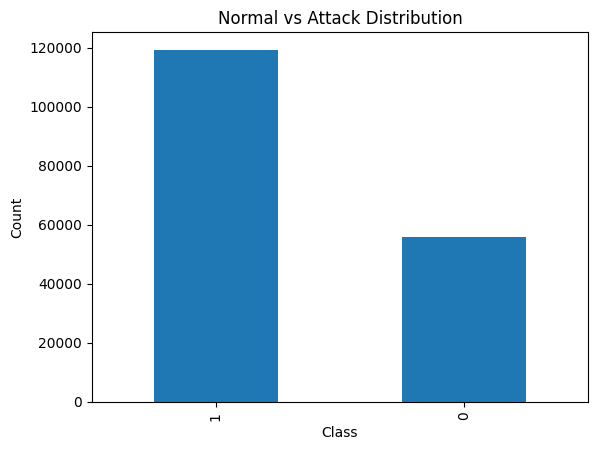

In [112]:
import matplotlib.pyplot as plt

train_df['label'].value_counts().plot(kind='bar')

plt.title("Normal vs Attack Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

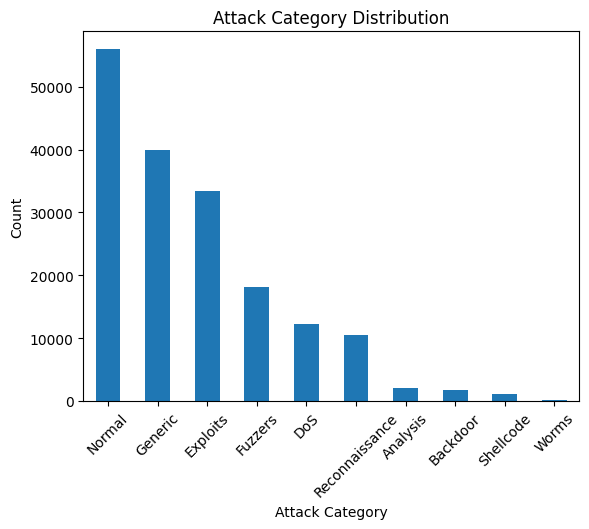

In [113]:
train_df['attack_cat'].value_counts().plot(kind='bar')
plt.title("Attack Category Distribution")
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Implementing the RandomForestClassifier on Attack

In [99]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

binary_model = RandomForestClassifier(random_state=42)

binary_model.fit(X_train_processed, y_train_binary)

y_pred_binary = binary_model.predict(X_test_processed)

print("Binary Classification Accuracy:")
print(accuracy_score(y_test_binary, y_pred_binary))

print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_binary))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, y_pred_binary))

Binary Classification Accuracy:
0.8705120730700092

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.73      0.84     37000
           1       0.82      0.98      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.90      0.86      0.86     82332
weighted avg       0.89      0.87      0.87     82332


Confusion Matrix:
[[27025  9975]
 [  686 44646]]


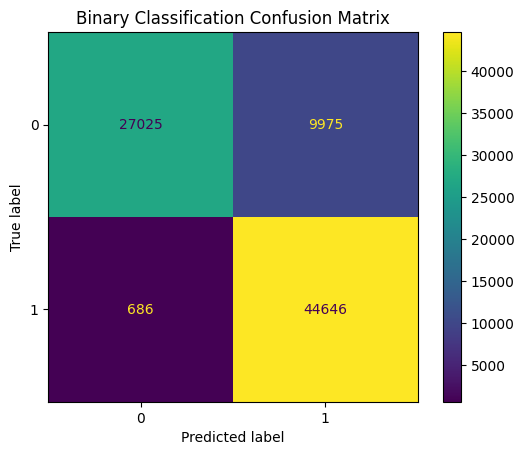

In [110]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test_binary,y_pred_binary)

plt.title("Binary Classification Confusion Matrix")
plt.show()

# Implementing the Logistic Regression on Attack

In [101]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_processed, y_train_binary)

y_pred_log = log_model.predict(X_test_processed)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test_binary, y_pred_log))

Logistic Regression Accuracy:
0.8097701987076714


# Implementing the Decision Tree Classifier on Attack

In [102]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(max_depth=15, random_state=42)

dt_model.fit(X_train_processed, y_train_binary)

y_pred_dt = dt_model.predict(X_test_processed)

print("Decision Tree Accuracy:")
print(accuracy_score(y_test_binary, y_pred_dt))

Decision Tree Accuracy:
0.8727226351843754


In [103]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Decision Tree"
    ],
    "Accuracy": [
        0.8097701987076714,
        0.8705120730700092,
        0.8727226351843754
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.809770
1,Random Forest,0.870512
2,Decision Tree,0.872723


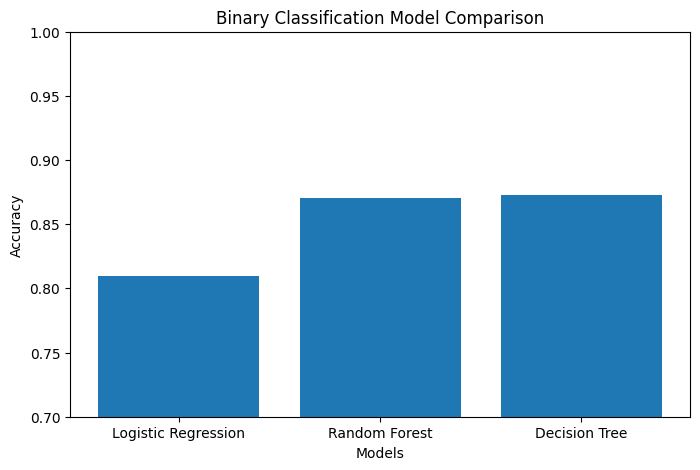

In [104]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Accuracy"])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Binary Classification Model Comparison")
plt.ylim(0.7, 1.0)
plt.show()

# DecisonTreeClassifier performed best

# Implementing the RandomForestClassifier on Attack Category

In [105]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

attack_model = RandomForestClassifier(
    n_estimators=30,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

attack_model.fit(
    X_train_attack_processed,
    y_train_attack_encoded
)

y_pred_attack = attack_model.predict(
    X_test_attack_processed
)

print("Attack Type Classification Accuracy:")

print(
    accuracy_score(
        y_test_attack_encoded,
        y_pred_attack
    )
)

Attack Type Classification Accuracy:
0.8026339009970882


In [106]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:\n")

print(
    classification_report(
        y_test_attack_encoded,
        y_pred_attack
    )
)

print("Confusion Matrix:\n")

print(
    confusion_matrix(
        y_test_attack_encoded,
        y_pred_attack
    )
)

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       677
           1       0.08      0.05      0.06       583
           2       0.79      0.05      0.10      4089
           3       0.59      0.94      0.72     11132
           4       0.86      0.76      0.81      6062
           5       1.00      0.96      0.98     18871
           6       0.95      0.77      0.85      3496
           7       0.61      0.59      0.60       378
           8       1.00      0.09      0.17        44

    accuracy                           0.80     45332
   macro avg       0.65      0.47      0.48     45332
weighted avg       0.83      0.80      0.77     45332

Confusion Matrix:

[[    0     1     2   674     0     0     0     0     0]
 [    0    27     2   543     8     0     0     3     0]
 [   89   128   219  3448   133     1    31    40     0]
 [   97   141    24 10420   330     0    74    46     0]
 [   11    12     6  135

In [125]:
import joblib
joblib.dump(dt_model, "binary_intrusion_model.pkl")
joblib.dump(attack_model, "attack_type_model.pkl")
joblib.dump(scaler, "binary_scaler.pkl")
joblib.dump(ohe, "binary_ohe.pkl")
joblib.dump(attack_scaler, "attack_scaler.pkl")
joblib.dump(attack_ohe, "attack_ohe.pkl")
joblib.dump(attack_label_encoder, "attack_label_encoder.pkl")
print("All models and preprocessing files saved successfully")

All models and preprocessing files saved successfully


In [118]:
import joblib
joblib.dump(
    X_train_binary.columns.tolist(),
    "original_binary_columns.pkl"
)

print("Original columns saved")

Original columns saved


In [119]:
joblib.dump(
    X_train_attack.columns.tolist(),
    "original_attack_columns.pkl"
)

print("Original attack columns saved")

Original attack columns saved


In [121]:
encoded_feature_names = (
    list(numerical) +
    list(ohe.get_feature_names_out(categorical))
)

joblib.dump(encoded_feature_names, "encoded_feature_names.pkl")

print(len(encoded_feature_names))
print("Encoded feature names saved")

194
Encoded feature names saved


In [122]:
attack_encoded_feature_names = (
    list(attack_numeric_cols) +
    list(attack_ohe.get_feature_names_out(attack_categorical_cols))
)

joblib.dump(attack_encoded_feature_names, "attack_encoded_feature_names.pkl")

print(len(attack_encoded_feature_names))
print("Attack encoded feature names saved")

186
Attack encoded feature names saved
